# HPD 2 — Agente analítico con Tool Calling

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/hpd2-agente-tool-calling.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> **Duración:** 4h
>
> **Competencias:** [CE-2](../index.qmd#sec-competencias-especificas)

> **Objetivos**
>
> - Construir un agente con LangChain y Tool Calling
> - Integrar herramientas de análisis de datos (pandas + visualización)
> - Implementar el patrón ReAct
> - Evaluar la capacidad del agente para responder preguntas en lenguaje
>   natural
>
> ## Materiales
>
> - Librerías: `langchain`, `langchain-openai`, `langchain-community`,
>   `pandas`, `matplotlib`, `seaborn`, `python-dotenv`
> - Dataset: Titanic (cargado inline con seaborn)
> - API key de Llamus US (`https://llamus.cs.us.es/api/v1`) o LLM local
>   con Ollama
>
> ## Pipeline
>
> 1.  **Setup:** cargar librerías, configurar LLM
> 2.  **Herramientas:** definir `@tool` para consultas pandas y
>     visualización
> 3.  **Agente ReAct:** construir el bucle de razonamiento + acción
> 4.  **Batería de pruebas:** evaluar con preguntas reales
> 5.  **Ejercicios:** extender el agente con nuevas capacidades

> **¿Por qué necesitas esto?**
>
> Imagina que tu jefe te escribe por Slack: *“¿qué producto creció más
> este trimestre?”*. Un agente autónomo recibe esa pregunta en lenguaje
> natural, decide consultar el CSV de ventas con pandas, calcula la
> respuesta y la devuelve. Sin que tú toques el código.
>
> Esa es la diferencia entre un **chatbot** (solo repite lo que sabe) y
> un **agente** (razona, decide qué herramienta usar, ejecuta y
> responde). En este taller construyes tu primer agente con el dataset
> Titanic. Pero la arquitectura que aprenderás (LLM + herramientas +
> bucle de decisión) es la misma para cualquier dataset de tu sector:
> ventas, finanzas, salud, legal, logística.

# Parte 1 — Setup

Empezamos instalando las dependencias necesarias y configurando el LLM.

In [ ]:
!pip install -q langchain langchain-openai langchain-community pandas matplotlib seaborn python-dotenv

In [ ]:
import os
"""
Setup compartido para la API key de Llamus en todos los notebooks.
Inyectado en cada .qmd/.ipynb vía scripts/sync_setup_keys.sh (pre-render).

Orden de resolución:
  1. .env local (python-dotenv)
  2. os.environ ya configurado externamente
  3. Google Colab userdata: secret "LLAMUS_API_KEY" (preferente) o "LLM_API_KEY"

Las celdas posteriores pueden leer la key con os.environ.get("LLM_API_KEY").
"""

import os


def _load_llm_api_key():
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass

    if not os.getenv("LLM_API_KEY"):
        try:
            from google.colab import userdata
            for name in ("LLAMUS_API_KEY", "LLM_API_KEY"):
                try:
                    value = userdata.get(name)
                    if value:
                        os.environ["LLM_API_KEY"] = value
                        break
                except Exception:
                    continue
        except ImportError:
            pass


_load_llm_api_key()

if os.getenv("LLM_API_KEY"):
    print("✓ LLM_API_KEY cargada.")
else:
    print("⚠️  LLM_API_KEY no encontrada.")
    print("    • Local: crea un archivo .env con LLM_API_KEY=tu_clave")
    print("    • Colab: añade un Secret 🔑 con nombre 'LLAMUS_API_KEY'")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import base64

plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

In [ ]:
from langchain_openai import ChatOpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz con:\n    LLM_API_KEY=tu_api_key\n    Las celdas con LLM mostrarán este aviso.")
else:
    llm = ChatOpenAI(model="mlx-community/Qwen3.6-35B-A3B-8bit", base_url=LLM_URL, api_key=LLM_KEY, temperature=0)
    print("✅ LLM configurado.")

# Parte 2 — Dataset: Titanic

Cargamos el dataset del Titanic para que el agente tenga datos reales
que analizar.

In [ ]:
df = sns.load_dataset("titanic")

print(f"Dataset Titanic: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
print()

# Breve exploración
print("--- Primeras filas ---")
display(df.head())

print("\n--- Tipos de datos ---")
display(df.dtypes)

print(f"\n--- Valores nulos ---")
for col in df.columns:
    nulos = df[col].isnull().sum()
    if nulos > 0:
        print(f"  {col}: {nulos} nulos ({nulos/len(df)*100:.1f}%)")

print(f"\nSupervivientes: {df['survived'].sum()} de {len(df)} ({df['survived'].mean()*100:.1f}%)")

In [ ]:
# Visualización rápida de referencia para usar más tarde
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["survived"].value_counts().plot.pie(autopct="%1.1f%%", labels=["No sobrevive", "Sobrevive"], ax=axes[0])
axes[0].set_title("Supervivencia")

df["pclass"].value_counts().sort_index().plot.bar(ax=axes[1], color=["#4B8BBE", "#306998", "#FFD43B"])
axes[1].set_title("Pasajeros por clase")
axes[1].set_xlabel("Clase")

df["age"].dropna().hist(bins=30, ax=axes[2], color="#2e7d32", edgecolor="white")
axes[2].set_title("Distribución de edad")
axes[2].set_xlabel("Edad")

plt.tight_layout()
plt.show()

# Parte 3 — Herramientas del agente

## Tool 1: consulta_pandas

Permite al LLM ejecutar expresiones de pandas sobre el DataFrame.

In [ ]:
from langchain.tools import tool

# ─── COMPLETAR: implementa la herramienta consulta_pandas ───
@tool
def consulta_pandas(expresion: str) -> str:
    """
    Ejecuta una expresión de pandas sobre el DataFrame df del Titanic y devuelve el resultado.
    
    El DataFrame 'df' tiene las columnas:
      survived (0=no, 1=sí), pclass (1,2,3), sex, age, sibsp, parch, fare, embarked (C,Q,S),
      class, who, adult_male, deck, embark_town, alive, alone.

    Args:
        expresion: expresión Python usando 'df' (ej: "df['age'].mean()",
                   "df.groupby('sex')['survived'].mean()")

    Returns:
        Resultado de la consulta como string.

    Ejemplo: consulta_pandas("df['fare'].max()") → '512.3292'
    """
    # TODO: Implementar eval seguro con sandbox limitado
    # Pista: usa eval(expresion, {"df": df, "pd": pd, "__builtins__": {}})
    # Captura excepciones con try/except y devuelve el error como string
    
    resultado = None  # ← completar
    return str(resultado)

In [ ]:
# Probar la herramienta directamente (sin LLM)
# Si la implementaste, estas líneas deberían funcionar:
print("=== Probando consulta_pandas (sin LLM) ===")
print("1. Media de edad:")
# print(consulta_pandas.invoke({"expresion": "df['age'].mean()"}))

print("2. Supervivencia por sexo:")
# print(consulta_pandas.invoke({"expresion": "df.groupby('sex')['survived'].mean()"}))

print("3. Pasajeros por clase:")
# print(consulta_pandas.invoke({"expresion": "df['pclass'].value_counts().sort_index()"}))

print("\n⚠️  Descomenta las líneas anteriores cuando hayas implementado la tool.")

## Tool 2: describe_schema

Fuente de verdad del esquema: el agente **no ve el DataFrame**, solo
sabe lo que le dicen los docstrings. Si duda del nombre exacto de una
columna (o no le queda claro qué contiene), debe llamar a
`describe_schema` antes de consultar. Esta tool ya viene implementada:

In [ ]:
@tool
def describe_schema() -> str:
    """
    Devuelve el esquema del DataFrame 'df' del Titanic: columnas, tipo de dato,
    valores nulos y valores únicos (para variables categóricas).

    Úsala siempre que necesites confirmar el nombre exacto de una columna
    (van en minúsculas: age, fare, sex, pclass...) o su contenido antes de consultar.

    Returns:
        String con el esquema completo del dataset.

    Ejemplo: describe_schema() → lista de columnas con tipo, nulos y valores únicos.
    """
    lineas = []
    for col in df.columns:
        nulos = df[col].isnull().sum()
        valores = ""
        if df[col].nunique() <= 10:
            valores = f" | valores: {sorted(df[col].dropna().unique().tolist())}"
        lineas.append(f"  {col}: {df[col].dtype}, {nulos} nulos{valores}")
    return "Esquema del dataset Titanic:\n" + "\n".join(lineas)

In [ ]:
# Probar describe_schema directamente (sin LLM)
print(describe_schema.invoke({}))

## Tools de visualización

Permiten al LLM generar gráficos con matplotlib sobre los datos del
Titanic.

In [ ]:
# ─── COMPLETAR: implementa las herramientas de visualización ───
@tool
def histograma(columna: str, titulo: str = "") -> str:
    """Genera un histograma de una columna numérica del Titanic (age, fare...).
    Los nombres de columna van en minúsculas (age, fare...), NO capitalizados (Age, Fare)."""
    # TODO: df[columna].hist() + plt.title(titulo)
    # Pista: guardar con plt.savefig("grafico.png") y cerrar con plt.close()
    pass  # ← completar

@tool
def barras(columna: str, agrupar_por: str = "") -> str:
    """Genera un gráfico de barras. 
    agrupar_por es opcional (sex, pclass...) para agrupar la media.
    Los nombres de columna van en minúsculas (sex, pclass...), NO capitalizados (Sex, Pclass)."""
    # TODO: value_counts().plot.bar() o groupby().mean().plot.bar()
    pass  # ← completar

@tool
def boxplot(columna: str, agrupar_por: str = "") -> str:
    """Genera un boxplot de una columna numérica (age, fare...). 
    agrupar_por es opcional para comparar entre categorías (sex, pclass...)."""
    # TODO: df.boxplot(columna) o df.boxplot(columna, by=agrupar_por)
    pass  # ← completar

In [ ]:
# Probar las herramientas directamente (sin LLM)
print("=== Probando herramientas de visualización (sin LLM) ===")
# print(histograma.invoke({"columna": "age", "titulo": "Distribución de edades"}))
# print(barras.invoke({"columna": "fare", "agrupar_por": "pclass"}))
# print(boxplot.invoke({"columna": "age", "agrupar_por": "sex"}))

print("⚠️  Descomenta las líneas anteriores cuando hayas implementado las tools.")

### Tool libre: código matplotlib arbitrario

Las 3 tools anteriores cubren los casos más comunes. Para gráficos más
complejos (dispersión, heatmap, 3D…), esta tool ejecuta código
matplotlib libre:

In [ ]:
from io import BytesIO

@tool
def codigo_libre(codigo: str) -> str:
    """
    Ejecuta código matplotlib libre sobre el DataFrame df del Titanic.
    Úsalo cuando ninguna otra tool sirva (dispersión, heatmap, 3D...).

    Args:
        codigo: código matplotlib. Variables: df, plt, pd, np.

    REGLAS (léelas):
    - Usa SIEMPRE plt.<funcion>(), NUNCA df.plot() ni seaborn
    - NO uses plt.show()
    - NO intentes leer archivos (df ya está cargado)
    - NO importes librerías (plt, pd, np ya disponibles)

    Ejemplo que FUNCIONA:
    plt.scatter(df['age'], df['fare'], c=df['survived'], cmap='viridis', alpha=0.5)
    plt.colorbar(label='Supervivencia')
    plt.xlabel('Edad'); plt.ylabel('Tarifa')
    """
    codigo = codigo.replace("plt.show()", "")
    try:
        plt.figure()
        exec(codigo, {"plt": plt, "pd": pd, "df": df, "np": np})
        buf = BytesIO()
        plt.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        plt.close()
        return f"Gráfico generado ({len(buf.getvalue())} bytes)"
    except Exception as e:
        plt.close()
        return f"Error: {e}. Reintenta con plt.<funcion>() en vez de df.plot() o seaborn"

# Probar codigo_libre
print("=== Probando codigo_libre (sin LLM) ===")
resultado = codigo_libre.invoke({
    "codigo": "plt.hist(df['age'].dropna(), bins=20, color='skyblue', edgecolor='black')\nplt.title('Distribución de Edades')\nplt.xlabel('Edad'); plt.ylabel('Frecuencia')"
})
print(f"  {resultado}")

> **Dos niveles de visualización**
>
> **Nivel básico:** `histograma`, `barras` y `boxplot` — parámetros
> simples, sin `exec()`. Fáciles de implementar y seguras.
>
> **Nivel avanzado:** `codigo_libre` — usa `exec()` para permitir
> cualquier gráfico. Más potente, pero requiere entender `exec()` y
> `BytesIO`.

# Parte 4 — Construir el agente ReAct

## Prompt del agente

Definimos el system prompt que le dice al modelo su rol y cómo usar las
herramientas.

In [ ]:
# ─── COMPLETAR: escribe el system prompt del agente ───
# Debe indicar:
#   - Rol: analista de datos del Titanic
#   - Qué herramientas tiene disponibles
#   - Cuándo usar cada una
#   - Formato de respuesta (conciso, profesional, en español)
#   - Que SIEMPRE use herramientas para responder preguntas sobre los datos
#   - Que consulte describe_schema() si no está seguro del nombre de las columnas
#     (van en minúsculas: age, fare, sex, pclass...) antes de hacer consultas

SYSTEM_PROMPT = """Eres un analista de datos experto en el dataset del Titanic.
# TODO: completar el resto del prompt
"""

print("System prompt configurado.")
print(f"System prompt actual ({len(SYSTEM_PROMPT)} caracteres):")
print(SYSTEM_PROMPT[:200] + "..." if len(SYSTEM_PROMPT) > 200 else SYSTEM_PROMPT)

## Crear el agente

In [ ]:
from langchain.agents import create_agent

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para crear el agente.")
else:
    # ─── COMPLETAR: crear el agente ───
    tools = [describe_schema, consulta_pandas, histograma, barras, boxplot, codigo_libre]
    
    # TODO: Crea el agente con create_agent:
    #   agente = create_agent(model=llm, tools=tools, system_prompt=SYSTEM_PROMPT)
    #   result = agente.invoke({"messages": [{"role": "user", "content": pregunta}]})
    #   print(result["messages"][-1].content)
    agente = None  # ← completar
    
    if agente:
        print("✅ Agente ReAct creado correctamente.")
    else:
        print("⚠️  Completa la creación del agente.")

# Parte 5 — Batería de pruebas

Probamos el agente con preguntas de dificultad creciente. Observa cómo
razona y qué herramientas elige.

In [ ]:
preguntas_prueba = [
    # Nivel 1: consulta simple → debería usar consulta_pandas
    "¿Cuál es la edad media de los pasajeros del Titanic?",
    
    # Nivel 2: agrupación → consulta_pandas
    "¿Qué porcentaje de mujeres sobrevivió comparado con los hombres?",
    
    # Nivel 3: visualización → histograma
    "Genera un histograma de la distribución de tarifas (fare)",
    
    # Nivel 4: barras + agrupar_por
    "¿Cuál es la tarifa media por clase? Haz un gráfico de barras",
    
    # Nivel 5: tool libre → codigo_libre
    "Haz un diagrama de dispersión (scatter) de edad vs tarifa, coloreando por supervivencia"
]

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver al agente en acción.")
elif agente is None:
    print("⚠️  Completa la creación del agente en la celda anterior.")
else:
    for i, pregunta in enumerate(preguntas_prueba, 1):
        print(f"\n{'='*70}")
        print(f"PREGUNTA {i}: {pregunta}")
        print('='*70)
        try:
            result = agente.invoke({"messages": [{"role": "user", "content": pregunta}]})
            print(f"\nRESPUESTA FINAL: {result['messages'][-1].content}")
        except Exception as e:
            print(f"ERROR: {e}")

## Tabla de evaluación

Completa esta tabla con tus observaciones sobre cada pregunta:

    ┌────┬──────────────────────────────────┬─────────────────┬──────────┬─────────────────────────┐
    │  # │ Pregunta                         │ Tool(s) usada   │ ¿Correcto?│ Observaciones           │
    ├────┼──────────────────────────────────┼─────────────────┼──────────┼─────────────────────────┤
    │  1 │ Edad media                       │                 │   / 5    │                         │
    │  2 │ Supervivencia por sexo           │                 │   / 5    │                         │
    │  3 │ Histograma tarifas               │                 │   / 5    │                         │
    │  4 │ Tarifa media por clase (barras)  │                 │   / 5    │                         │
    │  5 │ Dispersión edad vs tarifa        │                 │   / 5    │                         │
    └────┴──────────────────────────────────┴─────────────────┴──────────┴─────────────────────────┘

<figure id="fig-hpd2-agente-react">
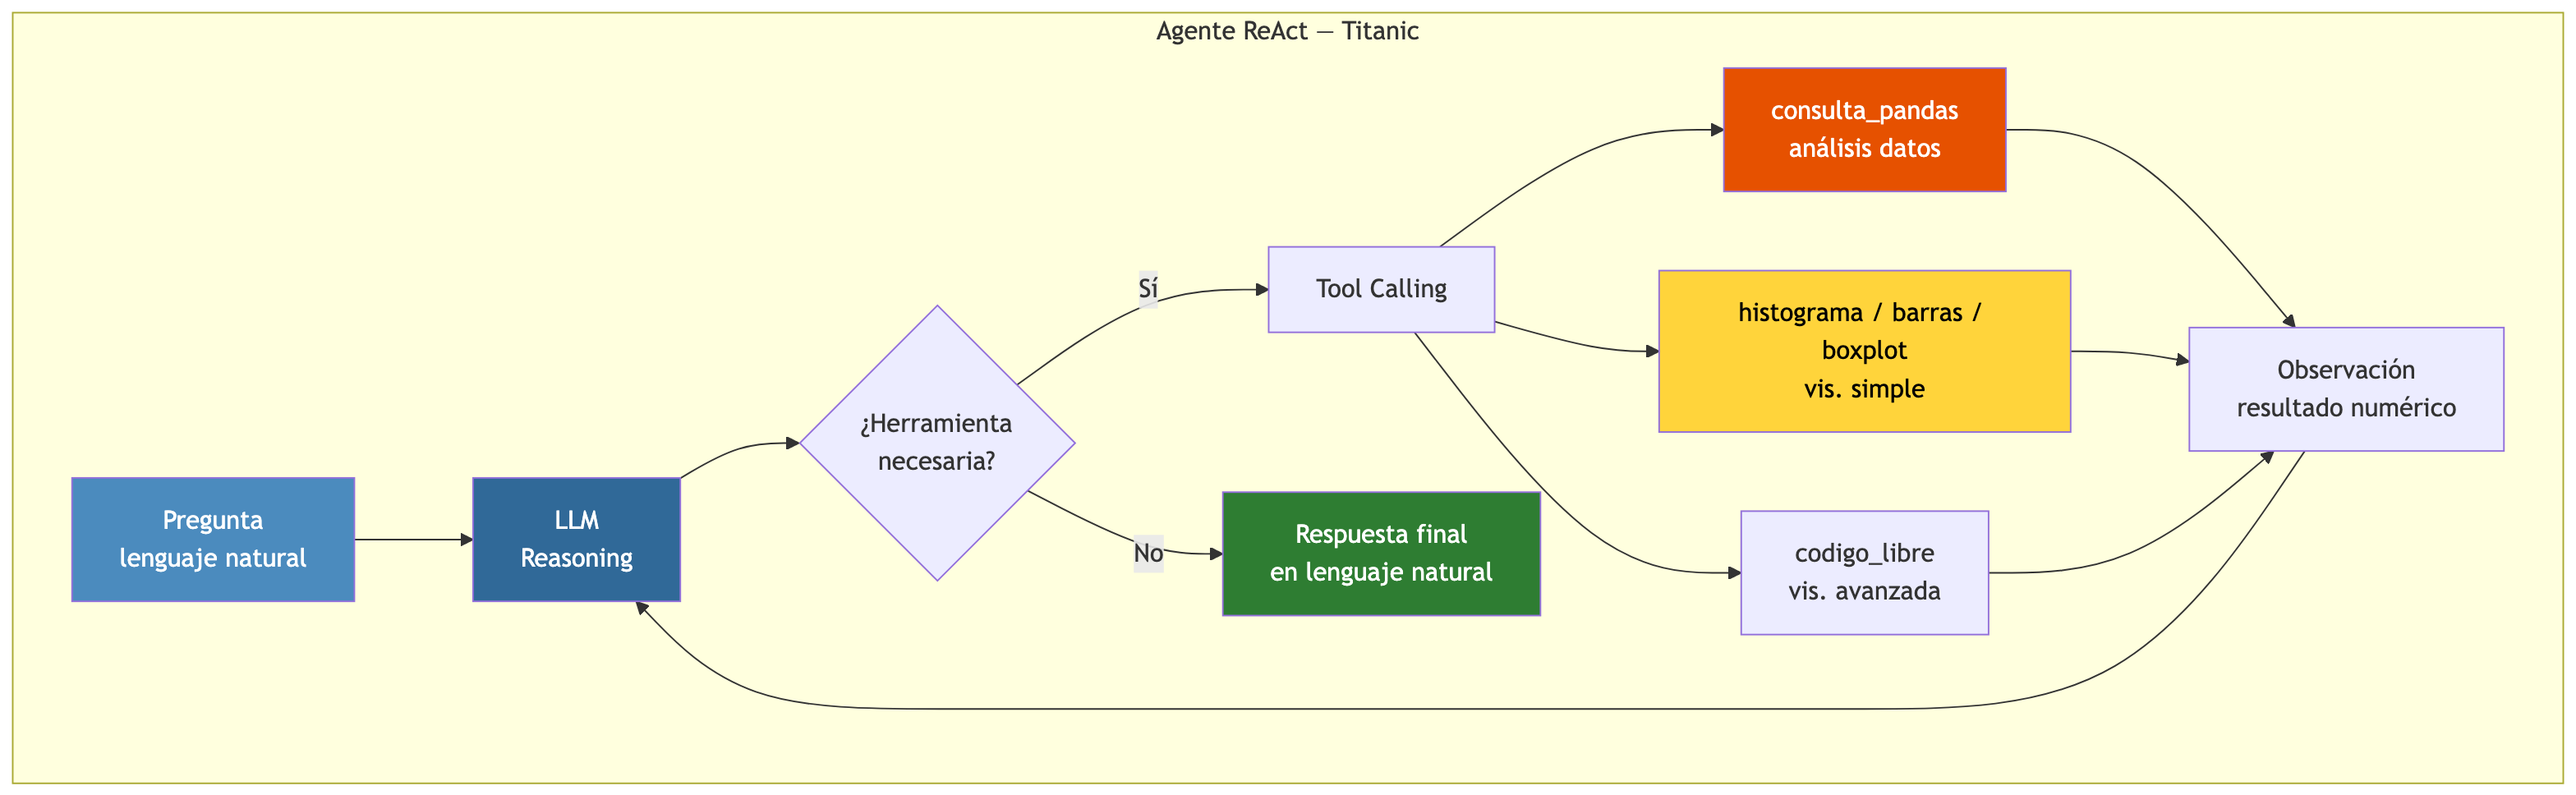
<figcaption>Figure 1</figcaption>
</figure>

------------------------------------------------------------------------

> **¿Siempre necesitas un agente?**
>
> No. Si tu flujo de trabajo es fijo (siempre los mismos pasos, mismo
> orden), una **cadena LCEL simple** es más rápida, más barata y más
> predecible. Usa un agente solo cuando el LLM necesite decidir qué
> herramienta usar **en tiempo real**. En producción, cada llamada extra
> al LLM cuesta tokens y añade latencia. La regla: empieza con una
> cadena simple. Si no basta, añade un agente.

# Ejercicios

> **Para afianzar lo aprendido (~45 min)**
>
> Estos ejercicios no se entregan, pero te preparan para el HPD 2
> evaluable y el proyecto integrador.
>
> ------------------------------------------------------------------------
>
> **A1 — Añade una tercera herramienta de análisis (~30 min)**
>
> Crea `@tool resumen_estadistico(columna: str)` que devuelva media,
> mediana, desviación estándar, mínimo y máximo de una columna numérica
> del DataFrame. Si la columna no es numérica o no existe, debe devolver
> un mensaje de error descriptivo.
>
> Prueba que tu agente la usa correctamente con preguntas como *“¿Cuál
> es el resumen estadístico de la columna fare?”*
>
> > **Note**
> >
> > **Objetivo:** entender que añadir herramientas es trivial si están
> > bien documentadas — el agente aprende a usarlas solo.
>
> ------------------------------------------------------------------------
>
> **A2 — Cambia el rol del agente (~15 min)**
>
> Modifica el `SYSTEM_PROMPT` para que el agente actúe como **guía
> turístico del Titanic** en vez de analista de datos. Debe responder en
> tono divulgativo, con contexto histórico, y solo usar herramientas si
> se lo piden explícitamente.
>
> Ejecuta las mismas 5 preguntas. ¿Cómo cambian las respuestas?
>
> > **Note**
> >
> > **Objetivo:** comprobar que el system prompt controla el
> > comportamiento del agente.
>
> ------------------------------------------------------------------------
>
> ### Para seguir explorando (opcional)
>
> **E1 — Manejo de errores robusto**
>
> Modifica `consulta_pandas` para que, cuando `eval()` falle, el mensaje
> de error incluya una **sugerencia de corrección** (p.ej. si la columna
> no existe, sugiere las columnas disponibles). Prueba preguntas con
> errores intencionados para ver si el agente se autocorrige.
>
> **E2 — Memoria conversacional**
>
> `create_agent` no guarda estado entre llamadas: cada `invoke` parte de
> cero. Para dar memoria al agente, acumula el historial en el campo
> `messages` de la siguiente invocación (reutiliza el
> `result["messages"]` de la llamada anterior y añade tu nueva
> pregunta). Haz 3 preguntas encadenadas donde la segunda y tercera
> dependan del contexto de las anteriores. Ejemplo: *“¿Cuántos pasajeros
> viajaban en primera clase?”* → *“¿Y cuántos de ellos sobrevivieron?”*
> → *“Compáralo con tercera clase.”*
>
> **E3 — Benchmark sin herramientas**
>
> Compara la precisión del agente **con herramientas** vs el mismo LLM
> **sin herramientas** (zero-shot, usando solo su conocimiento interno).
> ¿En qué tipo de preguntas gana el agente? ¿En cuáles no hay
> diferencia?

------------------------------------------------------------------------

> **Entregable**
>
> - Script Python del agente funcional con al menos 2 herramientas
> - Log de las 5 preguntas de prueba con sus respuestas
> - Tabla de evaluación completada
>
> ## Criterios de evaluación
>
> - Agente responde correctamente preguntas analíticas sobre el Titanic
> - Manejo de errores en ejecución de herramientas
> - Código modular y bien comentado
> - Las herramientas tienen docstrings completos (args, returns,
>   ejemplo)
>
> ## Tiempo estimado: 4h

# References